# EDA on Latest Weather Dataset

This notebook loads the latest `weather_hourly_YYYYMMDD_HHMMSS.csv` file from `data/processed/` and explores:

- time coverage and missingness
- summary tables for numeric and categorical columns
- unique values for categorical variables
- min / max ranges for numerical variables
- distributions and temporal plots for key weather signals
- hourly gaps in the raw weather feed

The dataset is already aggregated to one row per hour by `build_weather_dataset.py`.

In [14]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

In [15]:
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"


def latest_weather_file(processed_dir: Path) -> Path:
    candidates = sorted(
        path
        for path in processed_dir.glob("weather_hourly_*.csv")
        if re.fullmatch(r"weather_hourly_\d{8}_\d{6}\.csv", path.name)
    )
    if not candidates:
        raise FileNotFoundError("No timestamped weather CSV found in data/processed/.")
    return candidates[-1]

In [16]:
weather_path = latest_weather_file(PROCESSED_DIR)
weather = pd.read_csv(weather_path)

for col in ["hour_trunc", "first_timestamp", "last_timestamp"]:
    if col in weather.columns:
        weather[col] = pd.to_datetime(weather[col], errors="coerce")

print(f"Loaded weather file: {weather_path.name}")
print(f"Rows: {len(weather):,}")
print(f"Hour range: {weather['hour_trunc'].min()} -> {weather['hour_trunc'].max()}")
display(weather.head())

Loaded weather file: weather_hourly_20260607_115148.csv
Rows: 1,858
Hour range: 2026-03-15 14:00:00 -> 2026-05-31 23:00:00


,hour_trunc,raw_observation_count,first_timestamp,last_timestamp,temperature,precipitation,windspeed,weathercode,cloudcover,has_raw_observation
0,2026-03-15 14:00:00,2,2026-03-15 14:20:30,2026-03-15 14:50:54,18.050000,0.0,3.650000,0,10.0,True
1,2026-03-15 15:00:00,3,2026-03-15 15:00:06,2026-03-15 15:40:05,17.933333,0.0,8.733333,0,13.0,True
2,2026-03-15 16:00:00,1,2026-03-15 16:40:32,2026-03-15 16:40:32,17.100000,0.0,10.200000,1,38.0,True
3,2026-03-15 17:00:00,5,2026-03-15 17:00:52,2026-03-15 17:50:46,16.480000,0.0,9.320000,2,65.0,True
4,2026-03-15 18:00:00,1,2026-03-15 18:00:58,2026-03-15 18:00:58,15.900000,0.0,9.200000,1,38.0,True


## 1. Dataset Snapshot

The weather table is hourly. Each row represents one hour, with summary weather variables plus metadata that indicates whether raw source observations existed in that hour.

In [17]:
display(weather.describe(include="all").transpose())

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
hour_trunc,1858,NaN,NaN,NaN,2026-04-23 06:30:00.000000256,2026-03-15 14:00:00,2026-04-03 22:15:00,2026-04-23 06:30:00,2026-05-12 14:45:00,2026-05-31 23:00:00,NaN
raw_observation_count,1858.0,NaN,NaN,NaN,3.047901,0.0,1.0,2.0,6.0,6.0,2.088863
first_timestamp,1688,NaN,NaN,NaN,2026-04-24 05:36:32.918838784,2026-03-15 14:20:30,2026-04-04 20:45:20.500000,2026-04-24 07:05:25,2026-05-14 04:15:00,2026-05-31 23:00:00,NaN
last_timestamp,1688,NaN,NaN,NaN,2026-04-24 06:06:57.780805632,2026-03-15 14:50:54,2026-04-04 21:15:34.500000,2026-04-24 07:10:33,2026-05-14 05:05:00,2026-05-31 23:50:00,NaN
temperature,1858.0,NaN,NaN,NaN,16.783074,7.1,13.95,16.465,19.3,31.033333,4.237032
precipitation,1858.0,NaN,NaN,NaN,0.012099,0.0,0.0,0.0,0.0,0.94,0.071242
windspeed,1858.0,NaN,NaN,NaN,7.271984,0.0,4.05,6.0,10.0,28.5,4.463646
weathercode,1858.0,NaN,NaN,NaN,4.81916,0.0,0.0,1.0,3.0,95.0,15.074349
cloudcover,1858.0,NaN,NaN,NaN,44.417052,0.0,2.0,43.0,82.0,100.0,38.518402
has_raw_observation,1858,2,True,1688,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missingness Overview

This table shows which columns contain missing values in the hourly exploration dataset.

,missing_count,missing_pct
first_timestamp,170,9.149623
last_timestamp,170,9.149623
hour_trunc,0,0.000000
raw_observation_count,0,0.000000
temperature,0,0.000000
precipitation,0,0.000000
windspeed,0,0.000000
weathercode,0,0.000000
cloudcover,0,0.000000
has_raw_observation,0,0.000000


<Figure size 1000x600 with 0 Axes>

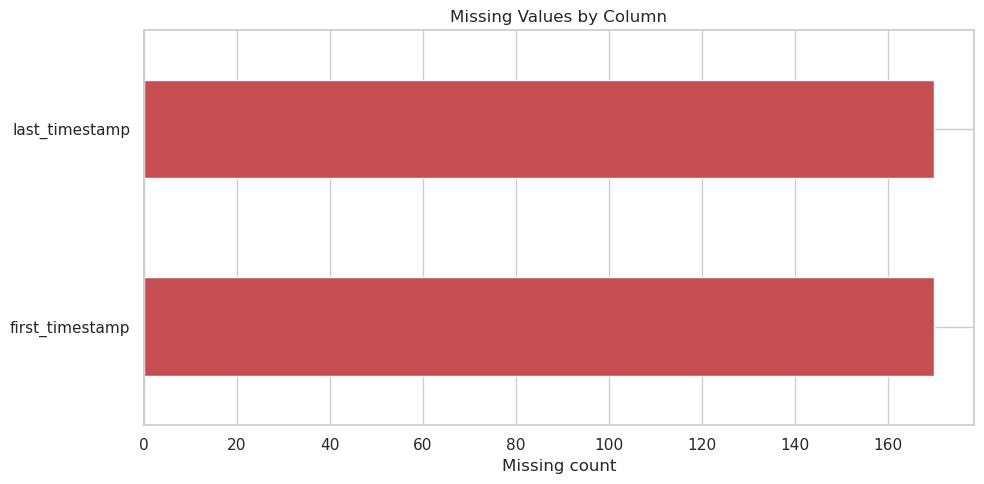

In [18]:
missing_summary = (
    pd.DataFrame({
        "missing_count": weather.isna().sum(),
        "missing_pct": 100 * weather.isna().mean(),
    })
    .sort_values("missing_count", ascending=False)
)
display(missing_summary)

plt.figure(figsize=(10, 6))
missing_summary.query("missing_count > 0").sort_values("missing_count").plot(
    kind="barh", y="missing_count", legend=False, color="#C44E52"
)
plt.title("Missing Values by Column")
plt.xlabel("Missing count")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 3. Categorical Columns: Unique Values

For weather exploration, the most relevant categorical-style columns are usually boolean / code columns rather than free-text categories.

This section lists unique values and their frequencies.

In [19]:
categorical_cols = ["has_raw_observation", "weathercode"]

for col in categorical_cols:
    print(f"\nUnique values for {col}:")
    display(weather[col].value_counts(dropna=False).rename_axis(col).reset_index(name="count"))


Unique values for has_raw_observation:


,has_raw_observation,count
0,True,1688
1,False,170



Unique values for weathercode:


,weathercode,count
0,0,615
1,2,402
2,3,398
3,1,343
4,80,33
5,61,31
6,45,22
7,63,7
8,95,6
9,81,1


## 4. Numerical Columns: Min / Max / Range

This section provides a compact table for the numeric weather variables, including min and max values.

In [20]:
numeric_cols = [
    "raw_observation_count",
    "temperature",
    "precipitation",
    "windspeed",
    "cloudcover",
]

numeric_summary = pd.DataFrame({
    "min": weather[numeric_cols].min(),
    "max": weather[numeric_cols].max(),
    "mean": weather[numeric_cols].mean(),
    "std": weather[numeric_cols].std(),
    "missing_count": weather[numeric_cols].isna().sum(),
}).sort_index()

display(numeric_summary)

,min,max,mean,std,missing_count
cloudcover,0.0,100.000000,44.417052,38.518402,0
precipitation,0.0,0.940000,0.012099,0.071242,0
raw_observation_count,0.0,6.000000,3.047901,2.088863,0
temperature,7.1,31.033333,16.783074,4.237032,0
windspeed,0.0,28.500000,7.271984,4.463646,0


## 5. Time Coverage and Gaps

The key diagnostic here is whether the source weather feed populated every hour. `has_raw_observation = False` means that hour exists in the hourly table only because we expanded to a complete hourly index.

In [21]:
coverage_summary = pd.DataFrame({
    "hours_with_raw_observation": [int(weather['has_raw_observation'].sum())],
    "hours_without_raw_observation": [int((~weather['has_raw_observation']).sum())],
    "pct_hours_without_raw_observation": [100 * (~weather['has_raw_observation']).mean()],
})
display(coverage_summary)

gap_rows = weather.loc[~weather['has_raw_observation'], ['hour_trunc']].copy()
print("First missing weather hours:")
display(gap_rows.head(30))

,hours_with_raw_observation,hours_without_raw_observation,pct_hours_without_raw_observation
0,1688,170,9.149623


First missing weather hours:


,hour_trunc
27,2026-03-16 17:00:00
28,2026-03-16 18:00:00
29,2026-03-16 19:00:00
30,2026-03-16 20:00:00
31,2026-03-16 21:00:00
35,2026-03-17 01:00:00
36,2026-03-17 02:00:00
38,2026-03-17 04:00:00
39,2026-03-17 05:00:00
40,2026-03-17 06:00:00


,service_date,total_hours,observed_hours,missing_hours
39,2026-04-23,24,16,8
48,2026-05-02,24,17,7
53,2026-05-07,24,18,6
3,2026-03-18,24,18,6
23,2026-04-07,24,18,6
1,2026-03-16,24,19,5
45,2026-04-29,24,19,5
15,2026-03-30,24,19,5
50,2026-05-04,24,19,5
2,2026-03-17,24,19,5


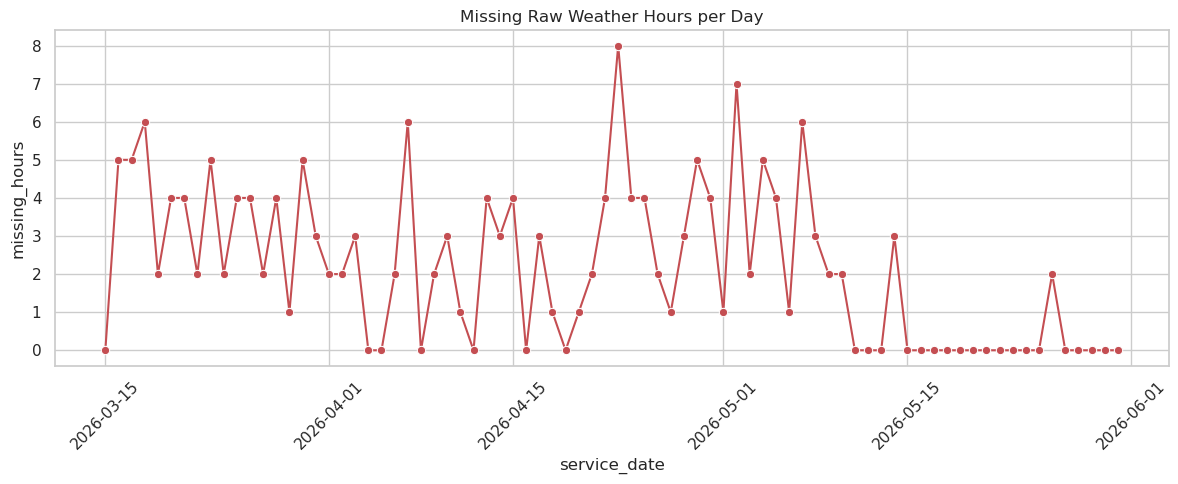

In [22]:
daily_coverage = (
    weather.assign(service_date=weather['hour_trunc'].dt.date)
    .groupby('service_date')
    .agg(
        total_hours=('hour_trunc', 'size'),
        observed_hours=('has_raw_observation', 'sum'),
    )
    .reset_index()
)
daily_coverage['missing_hours'] = daily_coverage['total_hours'] - daily_coverage['observed_hours']

display(daily_coverage.sort_values('missing_hours', ascending=False).head(15))

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_coverage, x='service_date', y='missing_hours', marker='o', color='#C44E52')
plt.title('Missing Raw Weather Hours per Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Distributions of Main Weather Variables

These histograms show the distribution of the main weather measurements across the hourly table.

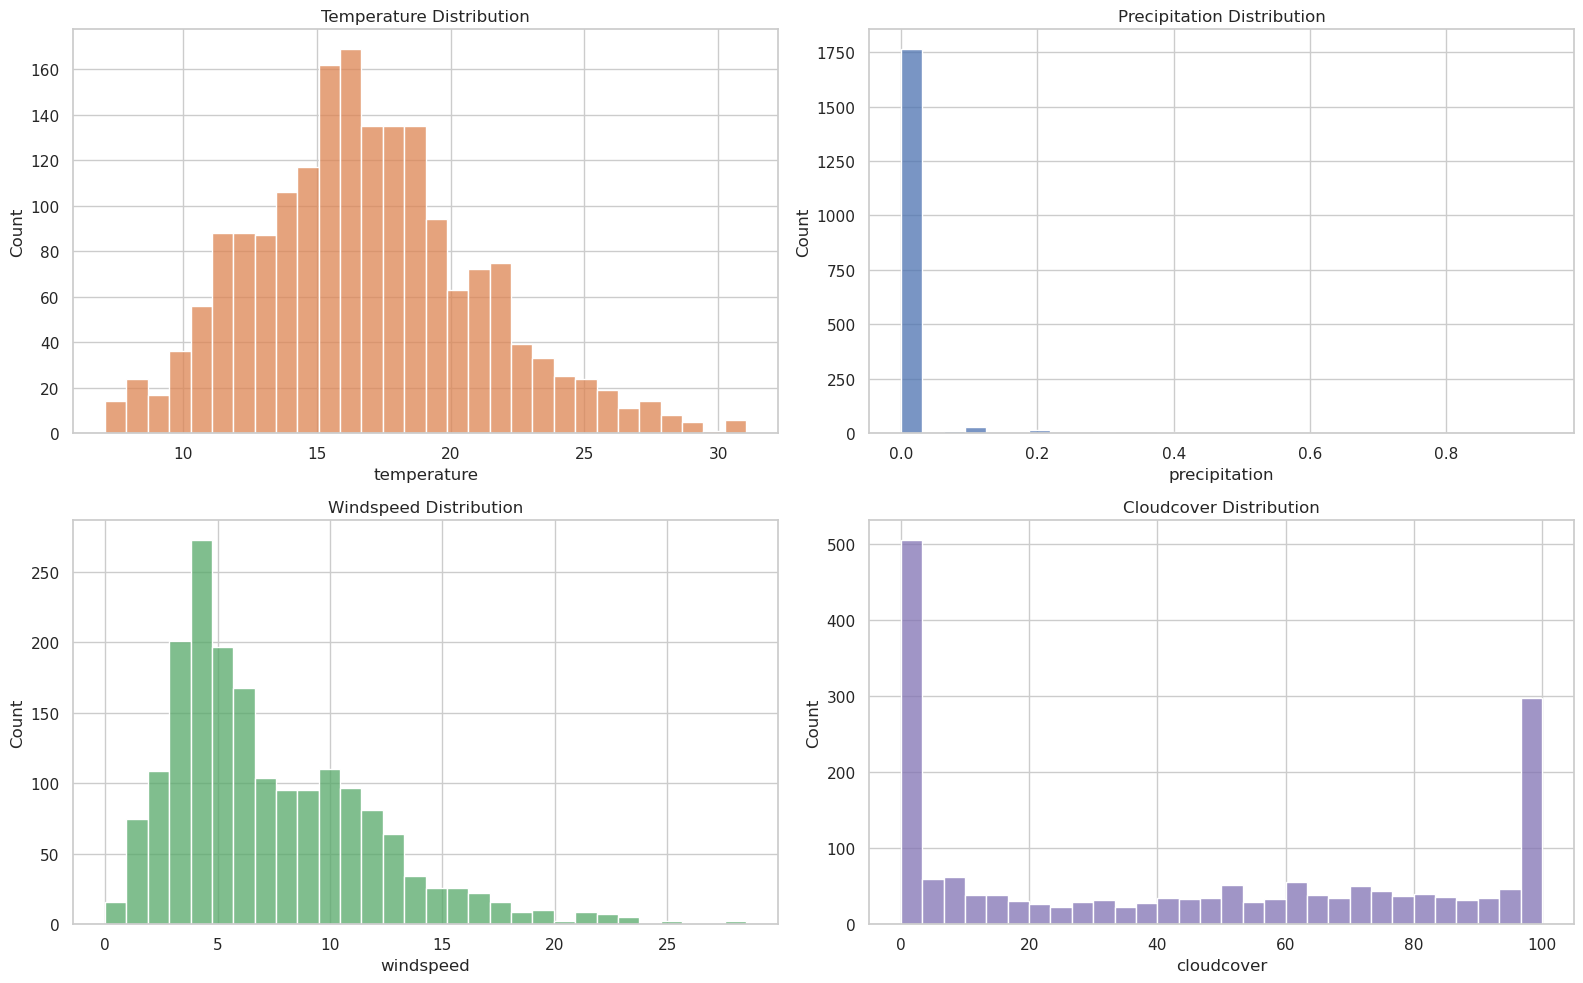

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(weather['temperature'].dropna(), bins=30, ax=axes[0, 0], color='#DD8452')
axes[0, 0].set_title('Temperature Distribution')

sns.histplot(weather['precipitation'].dropna(), bins=30, ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('Precipitation Distribution')

sns.histplot(weather['windspeed'].dropna(), bins=30, ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title('Windspeed Distribution')

sns.histplot(weather['cloudcover'].dropna(), bins=30, ax=axes[1, 1], color='#8172B3')
axes[1, 1].set_title('Cloudcover Distribution')

plt.tight_layout()
plt.show()

## 7. Weather Through Time

These plots show how the hourly variables evolve over time.

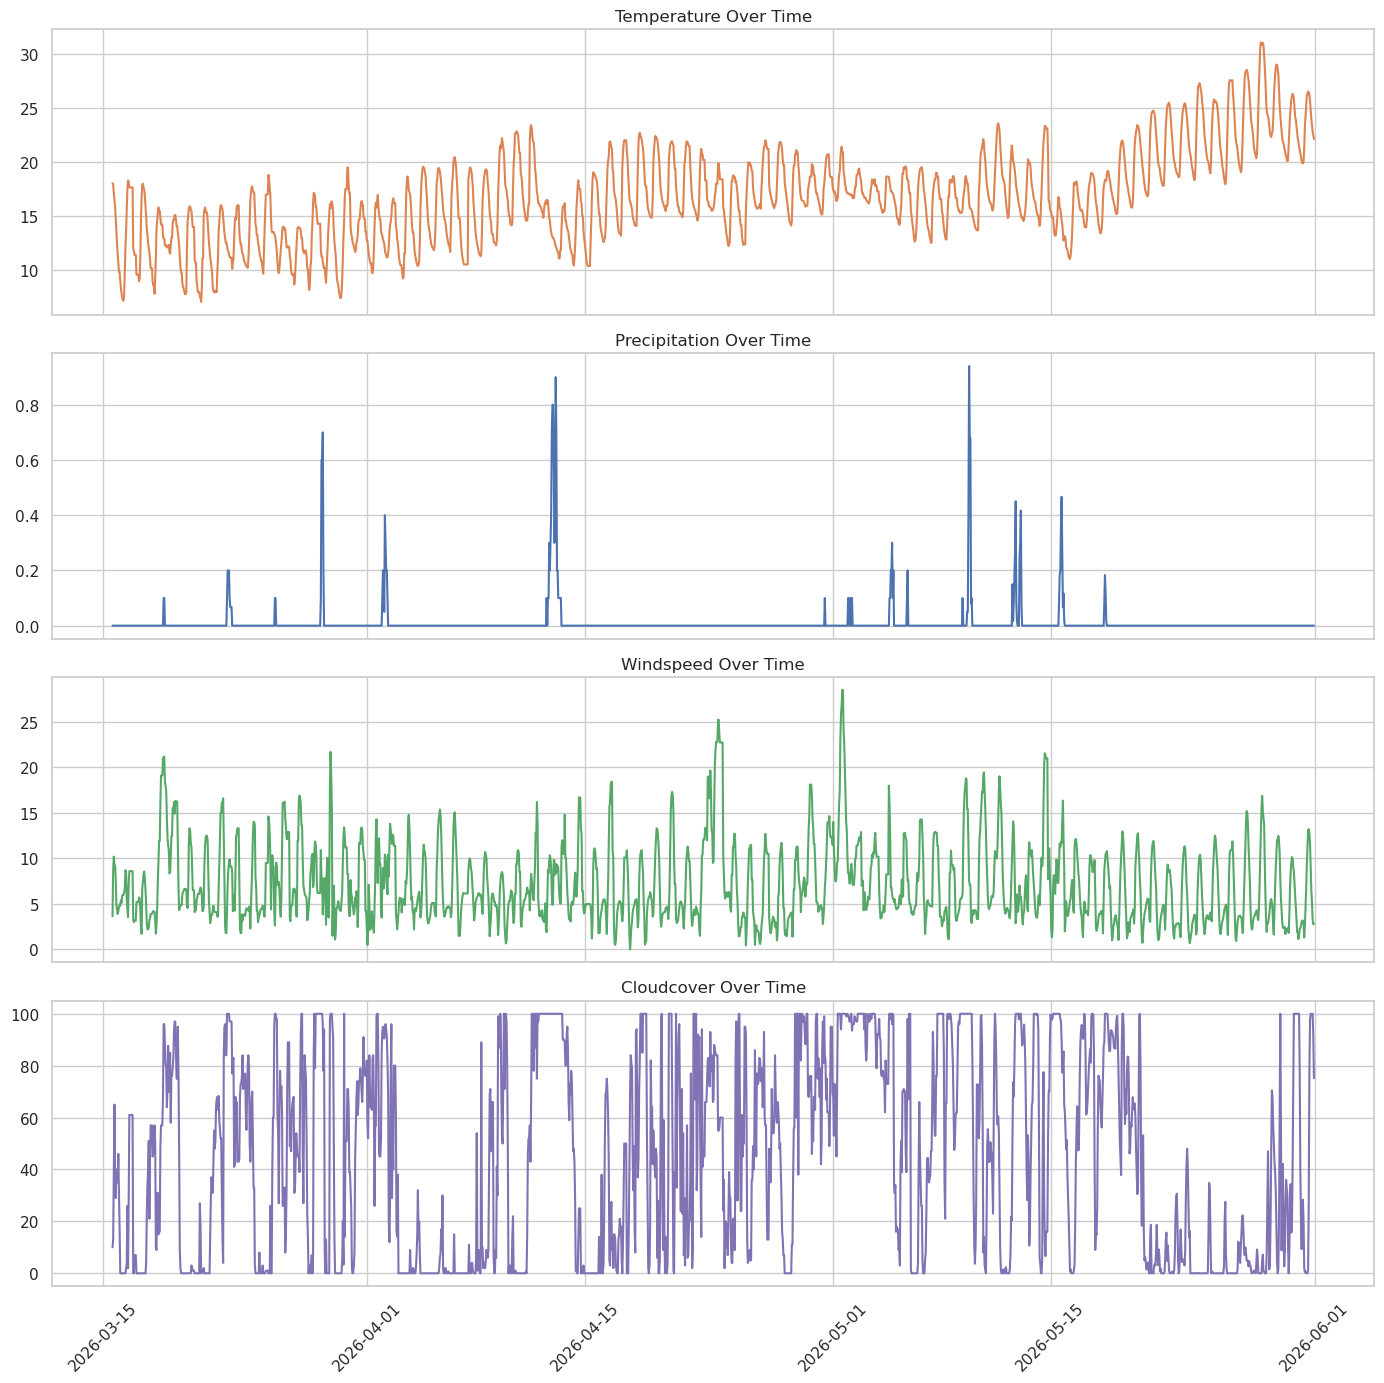

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(weather['hour_trunc'], weather['temperature'], color='#DD8452')
axes[0].set_title('Temperature Over Time')

axes[1].plot(weather['hour_trunc'], weather['precipitation'], color='#4C72B0')
axes[1].set_title('Precipitation Over Time')

axes[2].plot(weather['hour_trunc'], weather['windspeed'], color='#55A868')
axes[2].set_title('Windspeed Over Time')

axes[3].plot(weather['hour_trunc'], weather['cloudcover'], color='#8172B3')
axes[3].set_title('Cloudcover Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Hour-of-Day Patterns

A simple way to inspect weather seasonality is to average each variable by hour of day.

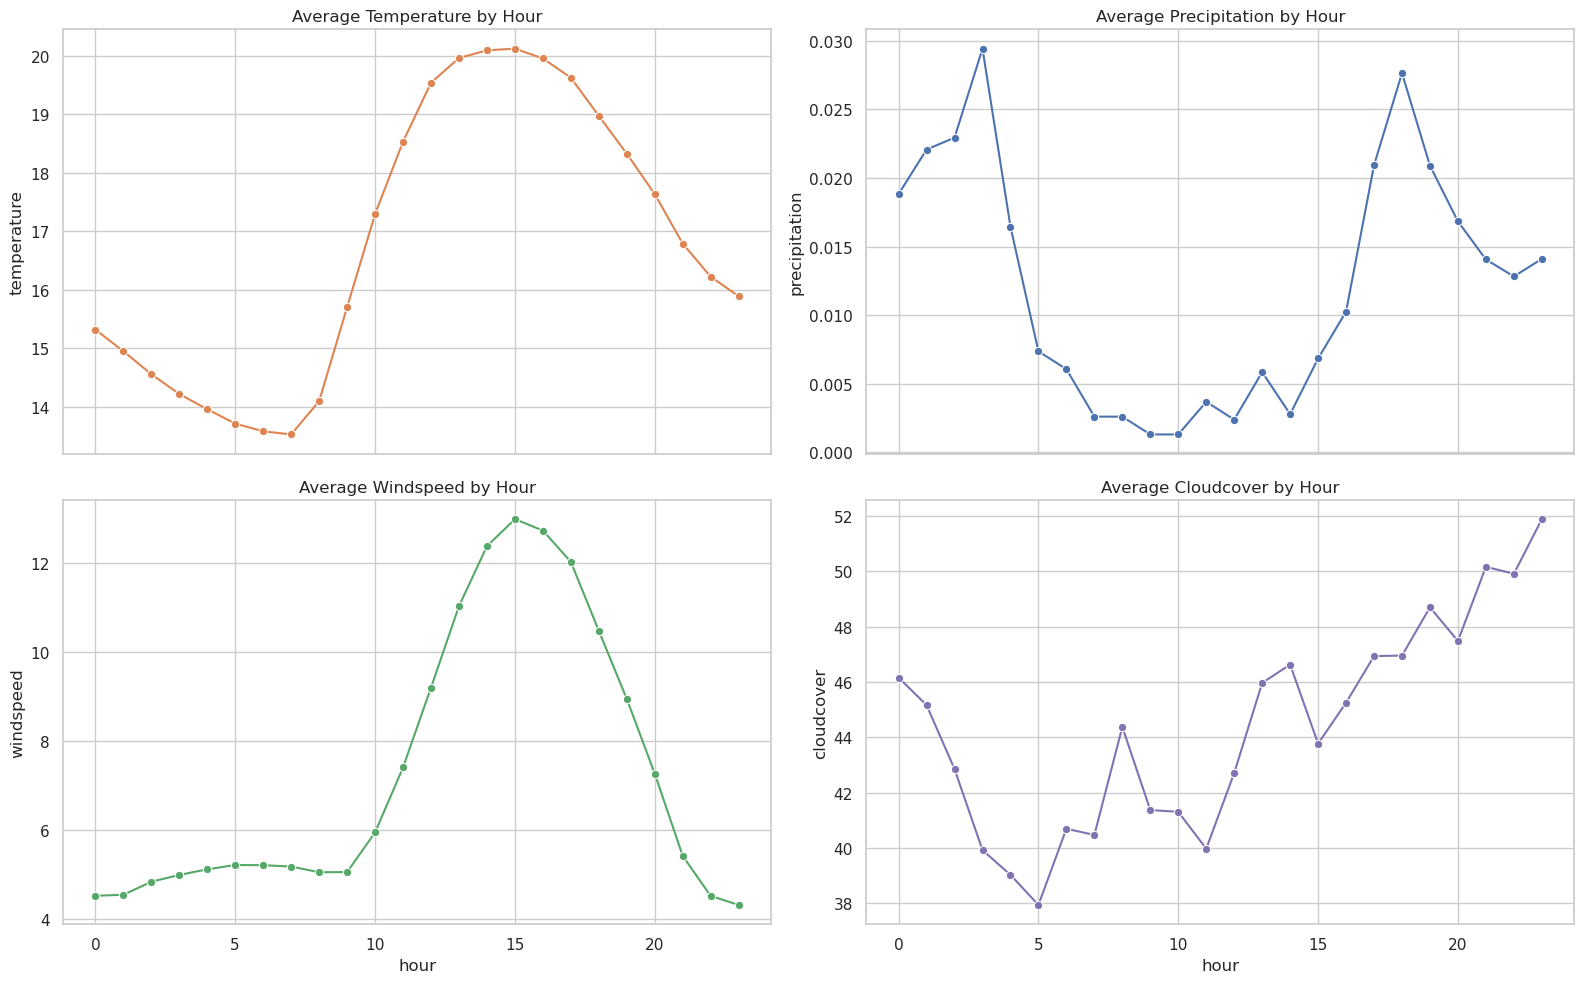

In [25]:
hourly_pattern = (
    weather.assign(hour=weather['hour_trunc'].dt.hour)
    .groupby('hour')
    .agg(
        temperature=('temperature', 'mean'),
        precipitation=('precipitation', 'mean'),
        windspeed=('windspeed', 'mean'),
        cloudcover=('cloudcover', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

sns.lineplot(data=hourly_pattern, x='hour', y='temperature', marker='o', ax=axes[0, 0], color='#DD8452')
axes[0, 0].set_title('Average Temperature by Hour')

sns.lineplot(data=hourly_pattern, x='hour', y='precipitation', marker='o', ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('Average Precipitation by Hour')

sns.lineplot(data=hourly_pattern, x='hour', y='windspeed', marker='o', ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title('Average Windspeed by Hour')

sns.lineplot(data=hourly_pattern, x='hour', y='cloudcover', marker='o', ax=axes[1, 1], color='#8172B3')
axes[1, 1].set_title('Average Cloudcover by Hour')

plt.tight_layout()
plt.show()

## 9. Weathercode Summary

Weather codes are useful as discrete condition labels. This table lists their observed frequencies.

,weathercode,count
0,0,615
1,2,402
2,3,398
3,1,343
4,80,33
5,61,31
6,45,22
7,63,7
8,95,6
9,81,1


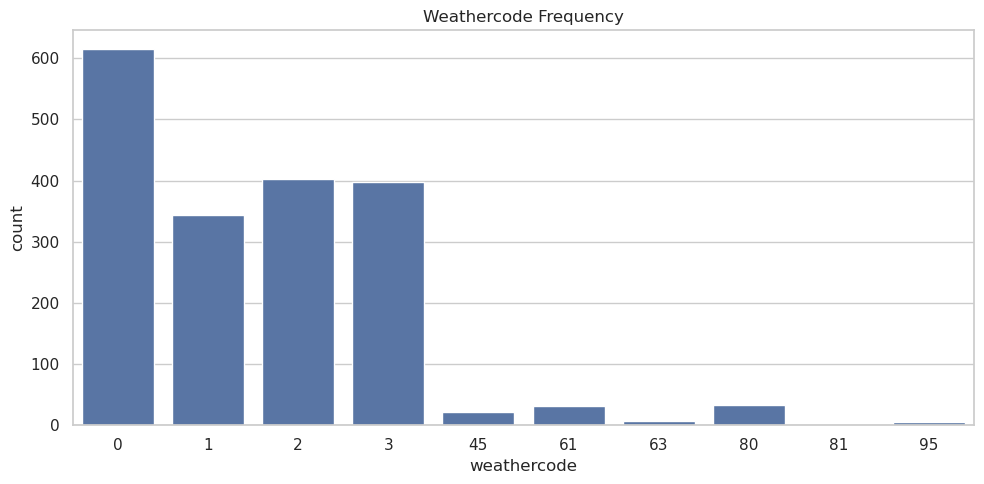

In [26]:
weathercode_summary = (
    weather['weathercode']
    .value_counts(dropna=False)
    .rename_axis('weathercode')
    .reset_index(name='count')
)
display(weathercode_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=weathercode_summary, x='weathercode', y='count', color='#4C72B0')
plt.title('Weathercode Frequency')
plt.tight_layout()
plt.show()

## 10. Interpretation Notes

- `has_raw_observation = False` identifies hours that were added when expanding the table to a complete hourly index.
- If many modeling rows later miss weather, this table is the right place to verify whether the issue is caused by gaps in the raw source feed.
- `weathercode` should be treated as a categorical signal in downstream models, while `temperature`, `precipitation`, `windspeed`, and `cloudcover` are numerical features.
- The min/max table is the quickest sanity check for unrealistic values or unit problems.